# LLM Repair Evaluation

Evaluate LLM-based repair and translation quality.

In [1]:
import os, json, sys, datetime
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from openai import OpenAI
from repair import PROMPTS
import sacrebleu
import pandas as pd
from normalization import strip_context


## Preparing the source data

In [2]:
# Importing gold set to list of dictionaries
with open("gold_set.jsonl", "r", encoding="utf-8") as file:
    gold_set = [json.loads(row) for row in file if row.strip()]
    
print(gold_set[1])

{'case_id': 'f02', 'category': 'fuzzy_real', 'query': 'plague ($type)', 'reference': 'zaraza ($type)', 'edit_type': 'addition', 'requires_agreement': 'no', 'flag': 'ok', 'comment': None, 'previous_source': 'plague', 'target_approved': 'zaraza', 'source_file': 'pl_help.po'}


In [3]:
necessary_fields = [
    "case_id",
    "category",
    "edit_type",
    "query",
    "reference"
]

additional_fields = [
    "target",
    "target_approved"
]

gold_set_filtered = []

for record in gold_set:
    new_record = {
        field: record.get(field)
        for field in necessary_fields
    }

    if record.get("category") == "edited" or record.get("category") == "fuzzy_real":
        new_record.update({
            field: record.get(field)
            for field in additional_fields
        })

    # Strip the Wesnoth gettext context prefix (e.g. "female^Drake Arbiter")
    # so the model sees clean text; keep the prefix as a separate hint field.
    context, query_norm = strip_context(record.get("query", ""))
    new_record["query_norm"] = query_norm
    new_record["context"] = context

    gold_set_filtered.append(new_record)

print(gold_set_filtered[0])

{'case_id': 'f01', 'category': 'fuzzy_real', 'edit_type': 'reworded', 'query': 'Pirate Flagship', 'reference': 'Okręt flagowy piratów', 'target': None, 'target_approved': 'Ogniste widmo', 'query_norm': 'Pirate Flagship', 'context': ''}


## Generating target translation

In [4]:
# Checking if a given version was already translated to avoid repeated generation
with open("prompt_runs.jsonl", "r", encoding="utf-8") as file:
    prompt_runs = [json.loads(row) for row in file if row.strip()]
    
print(prompt_runs[1])

{'ts': '2026-08-09T16:50:03', 'prompt_version': 'v1_only_different', 'model': 'gpt-4o-mini', 'fuzzy_score': 83.33333333333334, 'new_source': 'Elvish Runemaster', 'tm_source': 'Dwarvish Runemaster', 'tm_target': 'Krasnoludzki runmistrz', 'output': 'Elfi runmistrz'}


In [5]:
client = OpenAI()
model = os.getenv("OPENAI_MODEL", "gpt-4o")
target_language = "Polish"

In [6]:
def build_translation_messages(new_source: str, target_language: str, prompt_version: str) -> list:
    """Assemble the system + user messages for the translation call."""
    
    system = PROMPTS[prompt_version].format(target_language=target_language)

    user = f"""New source (English): {new_source}"""

    return [
        {"role": "system", "content": system},
        {"role": "user", "content": user},
    ]

In [7]:
def call_translation(messages: list, model: str, client: OpenAI) -> str:
    """Send the messages to the API and return the translation."""
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0,
    )
    return response.choices[0].message.content.strip()

In [8]:
def translate_segment(new_source, target_language, prompt_version, model, client):
    """Orchestration: build messages -> call LLM -> return translation."""
    messages = build_translation_messages(new_source, target_language, prompt_version)
    output = call_translation(messages, model, client)
    return output

In [9]:
# Example translation
prompt_version = "baseline_scratch"
new_source = gold_set_filtered[0]["query_norm"]
print(f"String to translate: {new_source}")
translation = translate_segment(new_source, target_language, prompt_version, model, client)
print(f"Translated string: {translation}")

String to translate: Pirate Flagship
Translated string: Piracki Okręt Flagowy


In [10]:
# Building cache
case_id = gold_set_filtered[0]["case_id"]
condition = "scratch"
prompt_version = "baseline_scratch"
cache = {}
key = (case_id, condition, prompt_version, model)
path = 'llm_runs.jsonl'


In [11]:
# Not used for now
def llm_log_run(path, prompt_version, model, output):
    """Logging function to record the details of each run."""
    rec = {
        "ts": datetime.datetime.now().isoformat(timespec="seconds"),
        "prompt_version": prompt_version,
        "model": model,
        "case_id": case_id,
        "condition": condition,
        "prompt_version": prompt_version,
        "output": output,
    }
    with open(path, "a", encoding="utf-8") as f:      # append: log grows over time
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

In [12]:
# Translating record and saving them to llm_runs log
for record in gold_set_filtered:
    new_source = record["query_norm"]
    output = translate_segment(new_source, target_language, "baseline_scratch", model, client)
    record["output"] = output
    record["condition"] = condition
    record["prompt_version"] = prompt_version
    record["model"] = model
    with open(path, "a", encoding="utf-8") as f:      # append: log grows over time
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


    


## Comparing the results with metrics

In [13]:
example_output = gold_set_filtered[10]["output"]
example_reference = gold_set_filtered[10]["reference"]
print(f"Example translation: {example_output} and its reference: {example_reference}")

Example translation: Jajo olbrzymiej mrówki and its reference: Jajo ogromnej mrówki


In [14]:
chrf_score = sacrebleu.sentence_chrf(example_output, [example_reference]).score
print(chrf_score)

50.36499757776167


In [15]:
# Generating CHRF score for the whole gold set
for record in gold_set_filtered:
    record["chrf"] = sacrebleu.sentence_chrf(record["output"], [record["reference"]]).score

In [16]:
# Transforming the gold set to pandas df for analysis
gold_set_df = pd.DataFrame(gold_set_filtered)
print(gold_set_df.head())

  case_id    category       edit_type  \
0     f01  fuzzy_real        reworded   
1     f02  fuzzy_real        addition   
2     f03  fuzzy_real  tag/formatting   
3     f04  fuzzy_real        addition   
4     f05  fuzzy_real        addition   

                                               query  \
0                                    Pirate Flagship   
1                                     plague ($type)   
2                            Campaigns and Scenarios   
3  <ref>dst='..calendar' text='Calendar'</ref>\n<...   
4                               Time of Day Schedule   

                                           reference target  \
0                              Okręt flagowy piratów    NaN   
1                                     zaraza ($type)    NaN   
2                             Kampanie i scenariusze    NaN   
3  <ref>dst='..calendar' text='Kalendarz'</ref>\n...    NaN   
4                                    Grafik pór dnia    NaN   

                                  tar

In [17]:
# Grouping the results by category
gold_set_df.groupby("category")["chrf"].mean()

category
edited        49.369083
fuzzy_real    45.831246
invented      61.661197
Name: chrf, dtype: float64

In [18]:
# Grouping the results by edit_type
gold_set_df.groupby("edit_type")["chrf"].mean()

edit_type
addition          57.721883
gender            19.896747
number            47.461457
omission          56.474099
reworded          55.306309
tag/formatting    59.083348
term              45.156585
Name: chrf, dtype: float64

In [19]:
gold_set_df.groupby("edit_type")["chrf"].size()

edit_type
addition          10
gender             7
number             4
omission           3
reworded           7
tag/formatting     6
term              23
Name: chrf, dtype: int64

In [20]:
gold_set_df[gold_set_df["case_id"].isin(["f09", "f24", "f27", "f26", "f15"])][["case_id", "query", "query_norm", "reference", "output"]]

,case_id,query,query_norm,reference,output
8,f09,female^Drake Arbiter,Drake Arbiter,Smocza strażniczka,Drake Arbiter
14,f15,male^Dark Horse,Dark Horse,Mroczny ogier,Czarny Koń
23,f24,female^Drake Clasher,Drake Clasher,Smocza bojowniczka,Drake Zderzacz
25,f26,female^Armageddon Drake,Armageddon Drake,Smoczyca zagłady,Armagedonowy Smok
26,f27,female^Drake Burner,Drake Burner,Smocza spalaczka,Drake Palnik


## Impact of the gettext context prefixes (the `^` strings)

Wesnoth stores a disambiguation context inline in the source, before a caret:
`female^Drake Arbiter`, `race^Merfolk`, `race+female^Horse`. In the first
baseline run these were sent to the model verbatim, so it treated the prefix as
text to translate or markup to keep (`female^Drake Arbiter -> "żeńska^Drake
Arbiter"`, `race^Merfolk -> "rasa^Morscy ludzie"`). Against a clean reference
chrF collapsed to near zero. That was a measurement artifact, not a
translation-quality failure.

Fix: normalization now lives in `src/normalization.py` as the single source of
truth. `strip_context` splits a source on the first caret into (context, text).
The translation memory is normalized at ingest into `source_norm` + `context`,
and here the eval query is stripped the same way before the model call
(`query_norm`), so both arms see clean text. The `^` prefix is kept as a
separate `context` field for later use as a grammatical hint.

Effect on the baseline (chrF by edit_type): the caret artifact is gone (no more
`^` in the outputs) and `term` rose from ~43 to ~46. But the `gender` bucket did
not move (20 -> 20). Inspecting those cases shows why: they are short Wesnoth
unit names like `Drake Arbiter -> "Smocza strażniczka"` where the approved
translation is game-specific terminology a from-scratch model cannot derive (it
echoes `Drake Arbiter` or translates literally to `Drake Zderzacz`), and where
the correct form also depends on grammatical gender (`Smok` vs `Smoczyca`) and
register (`Koń` vs `ogier`).

This is expected, and it is the point of the project: from-scratch translation
cannot reproduce approved terminology, so low baseline scores on exactly these
cases are the "before" that the repair arm is meant to beat. The residual gap is
a mix of terminology, register, and grammatical gender, and most of it is
recovered only by the repair step (which reuses the approved TM target), not by
the `female^`/`male^` hint alone. Pre-normalization numbers are kept above for
reference.

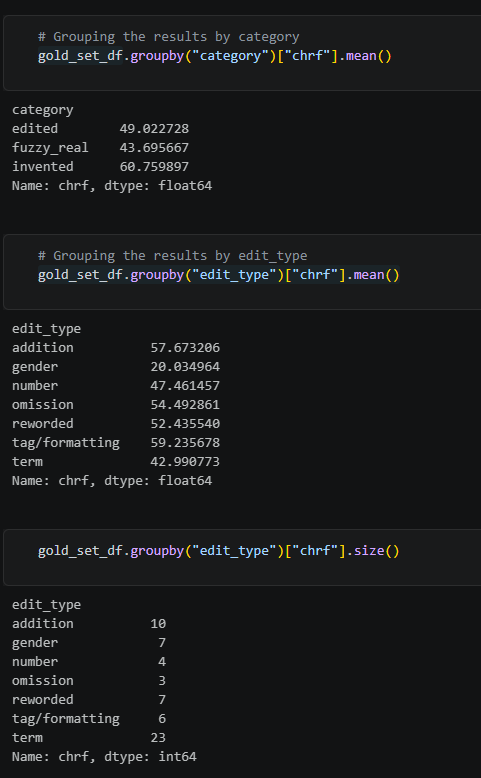

In [21]:
# Saving gold_set_df to CSV file

gold_set_df.to_csv('gold_set.csv', index=False, encoding = "utf-8")

## RAG Repair Results
Now, let's compare the results with a model that has access to translation memory as a RAG and knows that can use the context field to infer some additional information (basically the gender of a unit).

In [22]:
from repair import repair_segment, build_repair_messages, call_repair, PROMPTS

In [26]:
print(gold_set_filtered[0])

{'case_id': 'f01', 'category': 'fuzzy_real', 'edit_type': 'reworded', 'query': 'Pirate Flagship', 'reference': 'Okręt flagowy piratów', 'target': None, 'target_approved': 'Ogniste widmo', 'query_norm': 'Pirate Flagship', 'context': '', 'output': 'Piracki okręt flagowy', 'condition': 'scratch', 'prompt_version': 'baseline_scratch', 'model': 'gpt-4o-mini', 'chrf': 56.449702688092785}


In [ ]:
# Looping through the gold set to generate translations with v3
for record in gold_set_filtered:
    new_source = record["query_norm"]
    ctx = record["context"]
    ref_source = strip_context(record["target_approved"])
    ref_target = record["reference"]
    messages = build_repair_messages(new_source, "Polish", ref_source, ref_target, "v3_agreement", context=ctx)
    output_v3 = call_repair(messages, model, client)
    chrf_score_v3 = sacrebleu.sentence_chrf(output, [record["reference"]])

print(gold_set_filtered)  

KeyError: 'target_approved'